In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.simplefilter("ignore")

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 500)

In [3]:
def load():
  data = pd.read_csv("/kaggle/input/datasets/arhamrumi/amazon-product-reviews/Reviews.csv")
  return data

In [4]:
df = load()

## **Exploratory Data Analysis (EDA)**

In [5]:
def check_df(dataframe, head=5):
   print("#################  Shape  ####################")
   print(dataframe.shape)
   print("############  Types  ###########")
   print(dataframe.dtypes)
   print("#############  Head  ############")
   print(dataframe.head(head))
   print("##########  Tail  #########")
   print(dataframe.tail(head))
   print("##########  NA  ##########")
   print(dataframe.isnull().sum())
   print("##########  Quantiles  ########")
   print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)


#################  Shape  ####################
(568454, 10)
############  Types  ###########
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object
#############  Head  ############
   Id   ProductId          UserId                      ProfileName  HelpfulnessNumerator  HelpfulnessDenominator  Score        Time                Summary                                               Text
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian                     1                       1      5  1303862400  Good Quality Dog Food  I have bought several of the Vitality canned d...
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa                     0                       0     

### Explanation of columns

| Column Name | Description |
|-------------|-------------|
| Id | A unique identifier for each review record in the dataset. It represents the row number in the dataset. |
| ProductId | A unique identifier assigned to each product on Amazon. Multiple reviews may belong to the same product. |
| UserId | A unique identifier of the user who wrote the review. It helps identify which user reviewed which product. |
| ProfileName | The public display name of the user who wrote the review on Amazon. |
| HelpfulnessNumerator | The number of users who marked the review as helpful. |
| HelpfulnessDenominator | The total number of users who voted on the helpfulness of the review. |
| Score | The rating given by the user to the product. The rating typically ranges from 1 (lowest) to 5 (highest). |
| Time | The timestamp of when the review was posted, represented in Unix time format (seconds since January 1, 1970). |
| Summary | A short title or summary written by the user describing the review. |
| Text | The full text content of the user’s review, providing detailed feedback about the product. |

In [6]:
def grab_col_names(dataframe, cat_th = 5, car_th = 20):

 cat_cols = [col for col in dataframe.columns if dataframe[col].dtype in ["bool", "object", "category"]]

 num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                dataframe[col].dtype in ["int64", "float64"]]

 cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                dataframe[col].dtype in  ["object","category"]]

 cat_cols = cat_cols + num_but_cat

 cat_cols = [col for col in cat_cols if col not in cat_but_car]

 num_cols = [col for col in dataframe.columns if dataframe[col].dtype in ["int64","float64"] and col not in num_but_cat]


 print(f"Observations: {dataframe.shape[0]}")
 print(f"Variables: {dataframe.shape[1]}")
 print(f"cat_cols: {len(cat_cols)}")
 print(f"num_cols: {len(num_cols)}")
 print(f"num_but_cat: {len(num_but_cat)}")
 print(f"cat_but_car: {len(cat_but_car)}")
 return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)


Observations: 568454
Variables: 10
cat_cols: 0
num_cols: 5
num_but_cat: 0
cat_but_car: 5


In [7]:
cat_cols

[]

In [8]:
cat_but_car


['ProductId', 'UserId', 'ProfileName', 'Summary', 'Text']

In [9]:
num_cols

['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']

## Outlier Detection

In [10]:
def outlier_thresholds(dataframe, col_name, q1 = 0.25, q3 = 0.75):
  quartile1=dataframe[col_name].quantile(q1)
  quartile3=dataframe[col_name].quantile(q3)
  iqr = quartile3 - quartile1
  up_limit =quartile3 + iqr * 1.5
  low_limit = quartile1 - iqr * 1.5
  return low_limit, up_limit

In [11]:
def check_outlier(dataframe, col_name):
  low_limit, up_limit = outlier_thresholds(dataframe, col_name)

  if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
    return True
  else:
    return False


In [12]:
for col in num_cols:
  print(col, check_outlier(df, col))

Id False
HelpfulnessNumerator True
HelpfulnessDenominator True
Score True
Time True


In [13]:
#Numerical variable analysis

count    568454.000000
mean     284227.500000
std      164098.679298
min           1.000000
5%        28423.650000
10%       56846.300000
20%      113691.600000
30%      170536.900000
40%      227382.200000
50%      284227.500000
60%      341072.800000
70%      397918.100000
80%      454763.400000
90%      511608.700000
95%      540031.350000
99%      562769.470000
max      568454.000000
Name: Id, dtype: float64


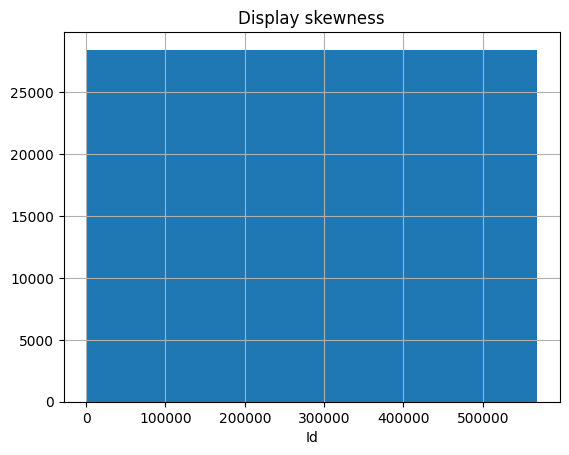

count    568454.000000
mean          1.743817
std           7.636513
min           0.000000
5%            0.000000
10%           0.000000
20%           0.000000
30%           0.000000
40%           0.000000
50%           0.000000
60%           1.000000
70%           1.000000
80%           2.000000
90%           4.000000
95%           7.000000
99%          19.000000
max         866.000000
Name: HelpfulnessNumerator, dtype: float64


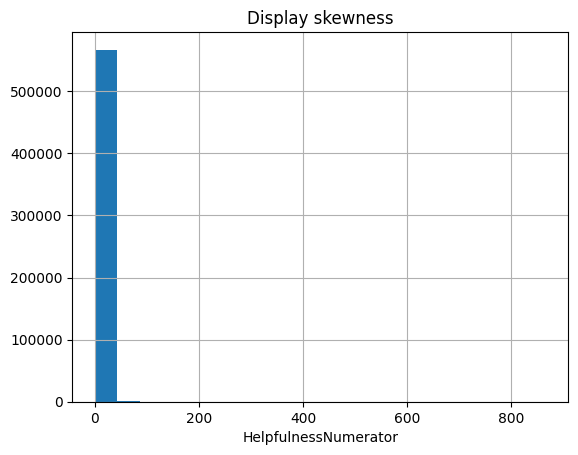

count    568454.00000
mean          2.22881
std           8.28974
min           0.00000
5%            0.00000
10%           0.00000
20%           0.00000
30%           0.00000
40%           0.00000
50%           1.00000
60%           1.00000
70%           2.00000
80%           3.00000
90%           5.00000
95%           9.00000
99%          23.00000
max         923.00000
Name: HelpfulnessDenominator, dtype: float64


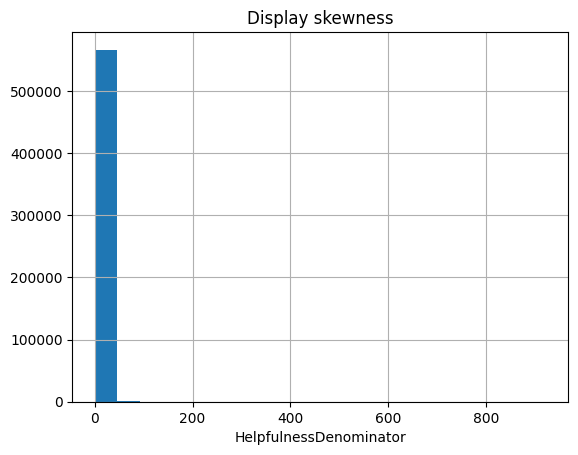

count    568454.000000
mean          4.183199
std           1.310436
min           1.000000
5%            1.000000
10%           2.000000
20%           3.000000
30%           4.000000
40%           5.000000
50%           5.000000
60%           5.000000
70%           5.000000
80%           5.000000
90%           5.000000
95%           5.000000
99%           5.000000
max           5.000000
Name: Score, dtype: float64


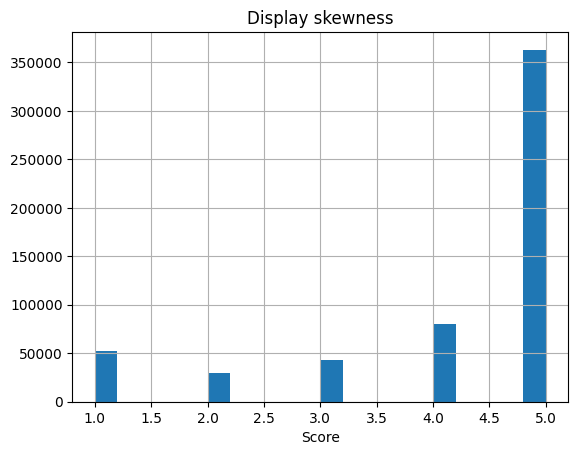

count    5.684540e+05
mean     1.296257e+09
std      4.804331e+07
min      9.393408e+08
5%       1.196035e+09
10%      1.224029e+09
20%      1.258675e+09
30%      1.283213e+09
40%      1.298333e+09
50%      1.311120e+09
60%      1.320970e+09
70%      1.328832e+09
80%      1.336608e+09
90%      1.344470e+09
95%      1.348013e+09
99%      1.350605e+09
max      1.351210e+09
Name: Time, dtype: float64


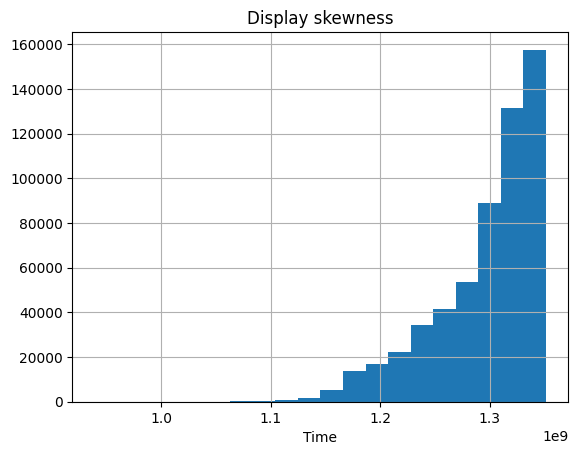

In [14]:
def num_summary (dataframe, numerical_col, plot=False):
  quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
  print(dataframe[numerical_col].describe(quantiles).T)

  if plot:
    dataframe[numerical_col].hist(bins=20)
    plt.xlabel(numerical_col)
    plt.title("Display skewness")
    plt.show()


for col in num_cols:
  num_summary(df, col, plot=True)

In [15]:
df = df.drop(columns=["Id", "ProfileName", "Summary", "Text"])

In [16]:
df.columns

Index(['ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time'], dtype='object')

In [17]:
df["review_time"] = pd.to_datetime(df["Time"], unit="s")

In [18]:
df["helpfulness_ratio"] = df["HelpfulnessNumerator"] / (df["HelpfulnessDenominator"] + 1)

#### Model data

In [19]:
df_rec = df[["UserId", "ProductId", "Score"]].copy()

In [20]:
#User filtering
user_counts = df_rec["UserId"].value_counts()
active_users = user_counts[user_counts >= 5].index
df_rec = df_rec[df_rec["UserId"].isin(active_users)]


In [21]:
#Product filtering
product_counts = df_rec["ProductId"].value_counts()
popular_products = product_counts[product_counts >= 5].index
df_rec = df_rec[df_rec["ProductId"].isin(popular_products)]

In [22]:
df_rec.shape

(195807, 3)

Her kullanıcı tum urunleri puanlamaz
bu yuzden az once yaptıgımız user filtering,
product filtering
aktif olan kullanıcıları cekmemizi, nan olmayan yorumları bulmamızı sagladı




In [23]:
#Active users:

In [24]:
print("Unique users: ", df_rec["UserId"].nunique())

Unique users:  22692


In [25]:
print("Unique products: ", df_rec["ProductId"].nunique())

Unique products:  6544


# Top 20 most active users

In [26]:
top_users = df_rec["UserId"].value_counts().head(20)

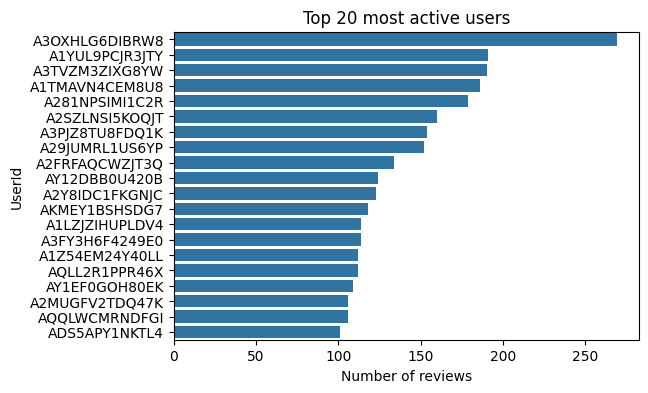

In [27]:
plt.figure(figsize=(6,4))
sns.barplot(x=top_users.values, y=top_users.index)

plt.title("Top 20 most active users")
plt.xlabel("Number of reviews")
plt.ylabel("UserId")

plt.show()

Text(0, 0.5, 'ProductId')

<Figure size 600x500 with 0 Axes>

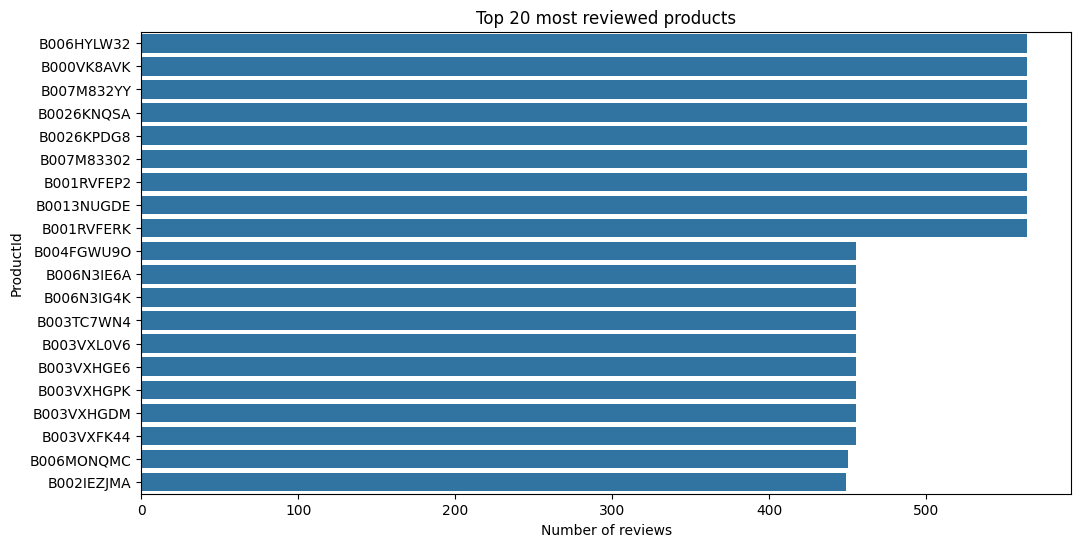

In [28]:
plt.figure(figsize=(6,5))

top_products = df_rec["ProductId"].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 20 most reviewed products")
plt.xlabel("Number of reviews")
plt.ylabel("ProductId")

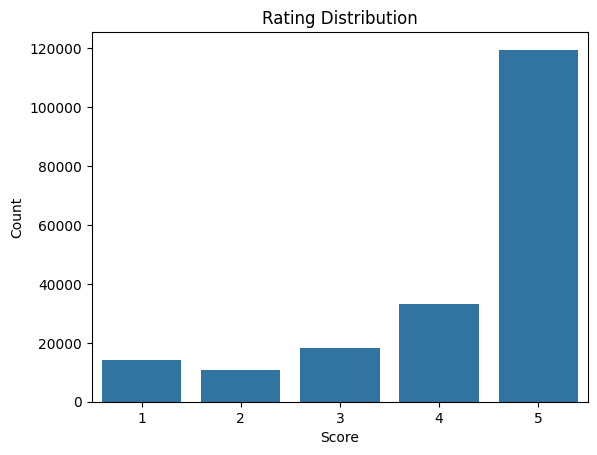

In [29]:
#Target value(Score) distribution
sns.countplot(data=df_rec, x="Score")

plt.title("Rating Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()

### Creating User-Item Matrix

In [30]:
user_item_matrix = df_rec.pivot_table(
    index="UserId",
    columns="ProductId",
    values="Score"

)


user_item_matrix.head()




ProductId       7310172001  7310172101  B00004CI84  B00004CXX9  B00004RAMY  B00004RBDU  B00004RBDZ  B00004RYGX  B00004S1C6  B000084DWM  B000084E6V  B000084ETV  B000084EZ4  B000084F1I  B000084F5E  B000084F6F  B00008CQVA  B00008DFK5  B00008JOL0  B00008MOIF  B00008Q3B7  B0000A1OEF  B0000AE5ZD  B0000AE5ZE  B0000CEPDP  B0000CEPED  B0000CEU6P  B0000CEU6T  B0000CEU7D  B0000CEU7J  B0000CFN0Y  B0000CGDUK  B0000DBN1F  B0000DBN1I  B0000DBN1L  B0000DBN2F  B0000DBN2I  B0000DGF9V  B0000DID5R  B0000DJ7RX  \
UserId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
A1001WMV1CL0XH         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A1004703RC79J9         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100IC7JRCQDUD         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100UZGZNZ9ZYN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100WO06OQR8BQ         NaN         NaN         NaN         NaN         NaN         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   

ProductId       B0000DJ7SR  B0000DJ7SW  B0000DJ7TL  B0000DJ7Z6  B0000DJ89V  B0000DJDJZ  B0000ESTGX  B0000GH6UG  B0000GH6UQ  B0000GHNSQ  B0000GHNTK  B0000GHNTU  B0000GHNUE  B0000GHNUO  B0000GHNUY  B0000GHNW2  B0000GHNWM  B0000GHXSG  B0000GHXSQ  B0000SY9U4  B0000SY9UE  B0000TSQ6G  B0000TSQ6Q  B0000V8IOE  B0000VLTZY  B0000VMA52  B0000W0GQQ  B0000W4PDQ  B00012182G  B00014DXCC  B00014FKPA  B00014H710  B00014HS2S  B00014IVPQ  B00014JNI0  B00014JYNO  B00014VTNW  B00016LA7K  B00016LA8E  B00016LA8Y  \
UserId         

In [31]:
user_item_matrix.shape

(22692, 6544)

### Rare product filtering


In [32]:
#Number of Product Reviews
product_counts = df_rec["ProductId"].value_counts()
product_counts.head()

ProductId
B006HYLW32    564
B000VK8AVK    564
B007M832YY    564
B0026KNQSA    564
B0026KPDG8    564
Name: count, dtype: int64

In [33]:
rare_products = product_counts[product_counts < 10].index

df_rec = df_rec[~df_rec["ProductId"].isin(rare_products)]

print("Filtered shape:", df_rec.shape)
print("Unique products:", df_rec["ProductId"].nunique())
print("Unique users:", df_rec["UserId"].nunique())

Filtered shape: (174259, 3)
Unique products: 3179
Unique users: 21232


### Product Review Distribution


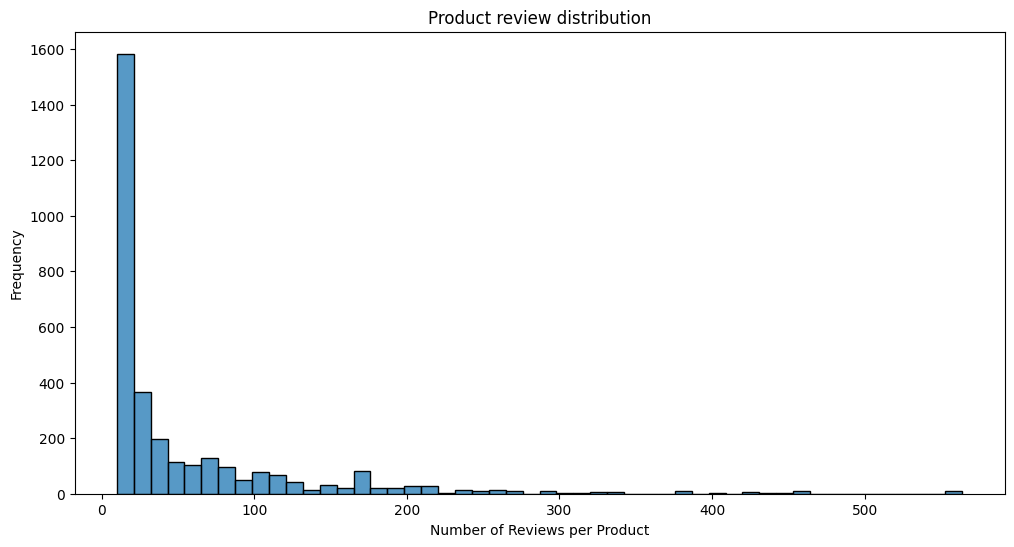

In [34]:
product_review_counts = df_rec["ProductId"].value_counts()

plt.figure(figsize=(12,6))
sns.histplot(product_review_counts, bins = 50)

plt.title("Product review distribution")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Frequency")

plt.show()

In [35]:
user_item_matrix = df_rec.pivot_table(
    index="UserId",
    columns="ProductId",
    values="Score"

)

print(user_item_matrix.shape)
user_item_matrix.head()

(21232, 3179)


ProductId       7310172001  7310172101  B00004CI84  B00004CXX9  B00004RYGX  B000084DWM  B000084E6V  B000084ETV  B000084EZ4  B000084F6F  B00008CQVA  B00008DFK5  B00008JOL0  B0000CEPED  B0000CEU6P  B0000CEU6T  B0000CEU7D  B0000CEU7J  B0000CGDUK  B0000DBN2I  B0000DJ7RX  B0000DJ7SR  B0000DJ7SW  B0000DJ7TL  B0000DJ7Z6  B0000DJDJZ  B0000SY9U4  B0000SY9UE  B0000TSQ6G  B0000TSQ6Q  B0000V8IOE  B00014DXCC  B00014FKPA  B00014H710  B00014JNI0  B00014JYNO  B00016LZT8  B00016UX0K  B00017LEXE  B00017LEXO  \
UserId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
A1004703RC79J9         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100IC7JRCQDUD         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100UZGZNZ9ZYN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100WO06OQR8BQ         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
A100ZQDV7L8PVV         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   

ProductId       B0001CXRKM  B0001CXUHW  B0001ES9F8  B0001ES9FI  B0001TPOY2  B00020HHAO  B00020HHE0  B00020HHGS  B00020HHHC  B00020HHK4  B00020HHM2  B00020HHRW  B00020XNTS  B00020XNU2  B00020XNUC  B00024D628  B00024D9X4  B00024DB5K  B00024DB6Y  B000255OIG  B00025YVH6  B000260M96  B00027CL5S  B00028HN5A  B00028MUDA  B00028P3CK  B00028PD7A  B0002ARQYQ  B0002DGJS2  B0002DGRPC  B0002DGRQ6  B0002DGRRA  B0002DGRSY  B0002DGRZC  B0002DHNXC  B0002DJNNK  B0002DJZX8  B0002E2GQU  B0002H3R2E  B0002I0GUY  \
UserId         

Rare product filtering was applied to remove products with very few reviews. Products with fewer than 10 reviews were excluded in order to reduce sparsity and improve the reliability of item-based similarity calculations.

### Build Item similarity matrix

In [36]:
item_similarity = user_item_matrix.corr()

item_similarity.head()

ProductId   7310172001  7310172101  B00004CI84  B00004CXX9  B00004RYGX  B000084DWM  B000084E6V  B000084ETV  B000084EZ4  B000084F6F  B00008CQVA  B00008DFK5  B00008JOL0  B0000CEPED  B0000CEU6P  B0000CEU6T  B0000CEU7D  B0000CEU7J  B0000CGDUK  B0000DBN2I  B0000DJ7RX  B0000DJ7SR  B0000DJ7SW  B0000DJ7TL  B0000DJ7Z6  B0000DJDJZ  B0000SY9U4  B0000SY9UE  B0000TSQ6G  B0000TSQ6Q  B0000V8IOE  B00014DXCC  B00014FKPA  B00014H710  B00014JNI0  B00014JYNO  B00016LZT8  B00016UX0K  B00017LEXE  B00017LEXO  \
ProductId                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
7310172001         1.0         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
7310172101         1.0         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
B00004CI84         NaN         NaN         1.0         1.0         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
B00004CXX9         NaN         NaN         1.0         1.0         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   
B00004RYGX         NaN         NaN         1.0         1.0         1.0         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN         NaN   

ProductId   B0001CXRKM  B0001CXUHW  B0001ES9F8  B0001ES9FI  B0001TPOY2  B00020HHAO  B00020HHE0  B00020HHGS  B00020HHHC  B00020HHK4  B00020HHM2  B00020HHRW  B00020XNTS  B00020XNU2  B00020XNUC  B00024D628  B00024D9X4  B00024DB5K  B00024DB6Y  B000255OIG  B00025YVH6  B000260M96  B00027CL5S  B00028HN5A  B00028MUDA  B00028P3CK  B00028PD7A  B0002ARQYQ  B0002DGJS2  B0002DGRPC  B0002DGRQ6  B0002DGRRA  B0002DGRSY  B0002DGRZC  B0002DHNXC  B0002DJNNK  B0002DJZX8  B0002E2GQU  B0002H3R2E  B0002I0GUY  \
ProductId                                      

In [37]:
import pandas as pd


def recommend_products(product_id, similarity_matrix, n=5):
    """
    Verilen bir ürün için en benzer n ürünü döndürür.
    
    Parametreler:
        product_id: Benzer ürünleri aranacak ürün
        similarity_matrix: Ürünler arası benzerlik matrisi
        n: Kaç benzer ürün getirileceği
    
    Döndürür:
        similar_products: similarity score'ları ile birlikte benzer ürünler
    """
    
    if product_id not in similarity_matrix.columns:
        return pd.Series(dtype=float)

    similar_scores = similarity_matrix[product_id]
    similar_products = similar_scores.sort_values(ascending=False)[1:n+1]

    return similar_products


def recommend_for_user(user_id, user_item_matrix, similarity_matrix, top_n=10, similar_n=5):
    """
    Belirli bir kullanıcı için item-based collaborative filtering ile ürün önerisi üretir.
    
    Mantık:
    1. Kullanıcının etkileşim verdiği ürünleri bul
    2. Her ürün için benzer ürünleri getir
    3. Benzerlik skorlarını topla
    4. Kullanıcının zaten sahip olduğu ürünleri çıkar
    5. En yüksek skorlu top_n ürünü öner
    
    Parametreler:
        user_id: Öneri yapılacak kullanıcı
        user_item_matrix: Satırlar kullanıcı, sütunlar ürün olan matris
        similarity_matrix: Ürünler arası benzerlik matrisi
        top_n: Sonuçta kaç ürün önerileceği
        similar_n: Her bir ürün için kaç benzer ürün dikkate alınacağı
    
    Döndürür:
        recommendation_scores: Önerilen ürünler ve skorları
    """

    if user_id not in user_item_matrix.index:
        raise ValueError(f"{user_id} user_id'si user_item_matrix içinde bulunamadı.")

    # Kullanıcının etkileşim verdiği ürünleri seç
    user_data = user_item_matrix.loc[user_id]

    # 0'dan büyük olanlar: kullanıcının aldığı / puanladığı / etkileşim verdiği ürünler
    interacted_products = user_data[user_data > 0].index.tolist()

    if len(interacted_products) == 0:
        return pd.Series(dtype=float)

    recommendation_scores = {}

    # Kullanıcının mevcut ürünlerinden yola çıkarak benzer ürünler topla
    for product in interacted_products:
        similar_products = recommend_products(product, similarity_matrix, n=similar_n)

        for similar_product, score in similar_products.items():
            if similar_product not in recommendation_scores:
                recommendation_scores[similar_product] = 0

            # Skoru topla
            recommendation_scores[similar_product] += score

    # Sözlüğü Series'e çevir
    recommendation_scores = pd.Series(recommendation_scores)

    # Kullanıcının zaten etkileşim verdiği ürünleri çıkar
    recommendation_scores = recommendation_scores.drop(
        labels=interacted_products,
        errors="ignore"
    )

    # Skora göre sırala ve top_n öneri döndür
    recommendation_scores = recommendation_scores.sort_values(ascending=False).head(top_n)

    return recommendation_scores

In [38]:
df.head()

,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,review_time,helpfulness_ratio
0,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,1303862400,2011-04-27,0.50
1,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,1346976000,2012-09-07,0.00
2,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,1219017600,2008-08-18,0.50
3,B000UA0QIQ,A395BORC6FGVXV,3,3,2,1307923200,2011-06-13,0.75
4,B006K2ZZ7K,A1UQRSCLF8GW1T,0,0,5,1350777600,2012-10-21,0.00


In [39]:
all_recommendations = {}

for user in user_item_matrix.index:
    recs = recommend_for_user(
        user_id=user,
        user_item_matrix=user_item_matrix,
        similarity_matrix=item_similarity,
        top_n=10
    )
    
    all_recommendations[user] = recs

In [40]:
#Sample user display
sample_user = user_item_matrix.index[0]

recommendations = all_recommendations[sample_user]

print(recommendations)

B000LKXCD6    2.0
B007OXJJPI    2.0
B000CQ01GU    2.0
B004YGQPAK    1.0
B001BS4G6O    1.0
B000QSON4K    1.0
B003E728CE    1.0
B000YSRK7E    1.0
B001AHFVHO    1.0
B000YSTIL0    1.0
dtype: float64


---
# İçerik Tabanlı Öneri Algoritmasının Uygulanması

Bu bölümde, mevcut item-based collaborative filtering sistemine ek olarak,
ürün yorumları üzerinden **TF-IDF** ve **CountVectorizer** kullanılarak
içerik tabanlı bir öneri sistemi geliştirilmektedir.

**Yaklaşım:**
1. Her ürün için tüm yorum metinleri birleştirilerek "ürün profili" oluşturulur
2. TF-IDF / CountVectorizer ile vektörleştirme yapılır
3. Cosine Similarity ile ürünler arası benzerlik matrisi hesaplanır
4. Kullanıcıların daha önce etkileşimde bulunduğu ürünlere benzer ürünler önerilir
5. Performans metrikleri (Precision@K, Recall@K, F1@K, Hit Rate) ile değerlendirme yapılır

## Veri Setini Yeniden Yükleme (Text & Summary Sütunları Dahil)

In [ ]:
# Text ve Summary sütunlarını kullanabilmek için veriyi tekrar yüklüyoruz
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

df_full = pd.read_csv("/kaggle/input/datasets/arhamrumi/amazon-product-reviews/Reviews.csv")
print(f"Tam veri seti boyutu: {df_full.shape}")
print(f"Sütunlar: {df_full.columns.tolist()}")

## Ürün Profili Oluşturma

Her ürün için tüm kullanıcı yorumları (`Text` ve `Summary`) birleştirilerek tek bir metin profili oluşturulur.
Bu profil, ürünün içerik açısından "ne hakkında" olduğunu temsil eder.

In [ ]:
# Sadece filtrelenmiş ürünleri kullanalım (mevcut recommendation sistemindeki ürünler)
filtered_products = df_rec["ProductId"].unique()
df_text = df_full[df_full["ProductId"].isin(filtered_products)][["ProductId", "Text", "Summary"]].copy()

# Eksik metinleri temizle
df_text["Text"] = df_text["Text"].fillna("")
df_text["Summary"] = df_text["Summary"].fillna("")

# Her ürün için tüm yorum metinlerini birleştir
product_profiles = df_text.groupby("ProductId").agg({
    "Text": lambda x: " ".join(x),
    "Summary": lambda x: " ".join(x)
}).reset_index()

# Text ve Summary'yi birleştirerek tek bir profil oluştur
product_profiles["combined_text"] = product_profiles["Summary"] + " " + product_profiles["Text"]

print(f"Toplam ürün profili sayısı: {len(product_profiles)}")
print(f"\nÖrnek ürün profili (ilk 300 karakter):")
print(product_profiles["combined_text"].iloc[0][:300])

## Metin Ön İşleme

In [ ]:
def clean_text(text):
    """
    Metin temizleme fonksiyonu:
    - Küçük harfe çevirme
    - HTML tag'lerini kaldırma
    - Özel karakterleri kaldırma
    - Fazla boşlukları temizleme
    """
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # HTML tag'leri
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # Özel karakterler
    text = re.sub(r'\s+', ' ', text).strip()     # Fazla boşluklar
    return text

product_profiles["clean_text"] = product_profiles["combined_text"].apply(clean_text)

print("Temizlenmiş örnek profil (ilk 300 karakter):")
print(product_profiles["clean_text"].iloc[0][:300])

## TF-IDF Vektörleştirme

**TF-IDF (Term Frequency - Inverse Document Frequency):** Bir kelimenin bir dokümandaki önemini ölçer.
- **TF:** Kelimenin dokümanda kaç kez geçtiği
- **IDF:** Kelimenin tüm dokümanlar arasındaki nadirligi
- Sık geçen ama az dokümanda bulunan kelimeler daha yüksek skor alır

In [ ]:
# TF-IDF Vektörleştirme
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # En önemli 5000 kelime
    stop_words='english',     # İngilizce stop words'leri çıkar
    ngram_range=(1, 2),       # Unigram ve bigram
    min_df=2,                 # En az 2 üründe geçen kelimeler
    max_df=0.95               # %95'ten fazla üründe geçen kelimeleri çıkar
)

tfidf_matrix = tfidf_vectorizer.fit_transform(product_profiles["clean_text"])

print(f"TF-IDF Matris Boyutu: {tfidf_matrix.shape}")
print(f"Özellik (kelime) sayısı: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"\nÖrnek özellikler (ilk 20):")
print(list(tfidf_vectorizer.get_feature_names_out()[:20]))

## CountVectorizer ile Vektörleştirme (Karşılaştırma İçin)

**CountVectorizer:** Kelimelerin frekansını sayar (TF-IDF'teki ağırlıklandırma olmadan).
Karşılaştırma amacıyla her iki yöntem de uygulanmaktadır.

In [ ]:
# CountVectorizer
count_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

count_matrix = count_vectorizer.fit_transform(product_profiles["clean_text"])

print(f"Count Matris Boyutu: {count_matrix.shape}")

## Benzerlik Matrisi Oluşturma (Cosine Similarity)

In [ ]:
# TF-IDF tabanlı cosine similarity
cosine_sim_tfidf = cosine_similarity(tfidf_matrix, tfidf_matrix)

# CountVectorizer tabanlı cosine similarity
cosine_sim_count = cosine_similarity(count_matrix, count_matrix)

print(f"TF-IDF Benzerlik Matrisi Boyutu: {cosine_sim_tfidf.shape}")
print(f"Count Benzerlik Matrisi Boyutu: {cosine_sim_count.shape}")

# Ürün ID'lerini indeksleme (hızlı arama için)
product_id_to_idx = {pid: idx for idx, pid in enumerate(product_profiles["ProductId"])}
idx_to_product_id = {idx: pid for pid, idx in product_id_to_idx.items()}

## İçerik Tabanlı Öneri Fonksiyonları

In [ ]:
def content_based_recommend(product_id, similarity_matrix, product_id_map, n=5):
    """
    İçerik tabanlı ürün önerisi.
    Verilen ürüne en benzer n ürünü döndürür.
    
    Parametreler:
        product_id: Hedef ürün ID'si
        similarity_matrix: Cosine similarity matrisi
        product_id_map: ProductId -> index eşlemesi
        n: Kaç öneri döndürüleceği
    
    Döndürür:
        pd.Series: Önerilen ürün ID'leri ve benzerlik skorları
    """
    if product_id not in product_id_map:
        return pd.Series(dtype=float)
    
    idx = product_id_map[product_id]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Kendisini çıkar ve benzerlik skoruna göre sırala
    sim_scores = [(i, score) for i, score in sim_scores if i != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Top N
    top_n = sim_scores[:n]
    
    result = pd.Series(
        {idx_to_product_id[i]: score for i, score in top_n}
    )
    
    return result


def content_based_recommend_for_user(user_id, user_item_matrix, similarity_matrix, 
                                     product_id_map, top_n=10, similar_n=5):
    """
    Kullanıcı için içerik tabanlı öneri üretir.
    
    Mantık:
    1. Kullanıcının etkileşim verdiği ürünleri bul
    2. Her ürün için içerik benzerliğine göre benzer ürünleri getir
    3. Benzerlik skorlarını topla
    4. Kullanıcının zaten etkileşim verdiği ürünleri çıkar
    5. En yüksek skorlu top_n ürünü döndür
    
    Parametreler:
        user_id: Öneri yapılacak kullanıcı
        user_item_matrix: UserId x ProductId matrisi
        similarity_matrix: İçerik tabanlı cosine similarity matrisi
        product_id_map: ProductId -> index eşlemesi
        top_n: Kaç ürün önerileceği
        similar_n: Her ürün başına kaç benzer ürün
    
    Döndürür:
        pd.Series: Önerilen ürün ID'leri ve skorları
    """
    if user_id not in user_item_matrix.index:
        return pd.Series(dtype=float)
    
    user_data = user_item_matrix.loc[user_id]
    interacted_products = user_data[user_data > 0].index.tolist()
    
    if len(interacted_products) == 0:
        return pd.Series(dtype=float)
    
    recommendation_scores = {}
    
    for product in interacted_products:
        similar = content_based_recommend(
            product, similarity_matrix, product_id_map, n=similar_n
        )
        
        for similar_product, score in similar.items():
            if similar_product not in recommendation_scores:
                recommendation_scores[similar_product] = 0
            recommendation_scores[similar_product] += score
    
    recommendation_scores = pd.Series(recommendation_scores)
    recommendation_scores = recommendation_scores.drop(
        labels=interacted_products, errors="ignore"
    )
    
    return recommendation_scores.sort_values(ascending=False).head(top_n)


print("İçerik tabanlı öneri fonksiyonları tanımlandı.")

## Örnek Öneri Çıktıları

In [ ]:
# Örnek bir ürün için içerik tabanlı öneri
sample_product = product_profiles["ProductId"].iloc[0]
print(f"Hedef Ürün: {sample_product}")
print(f"\n--- TF-IDF Tabanlı Öneriler ---")
tfidf_recs = content_based_recommend(sample_product, cosine_sim_tfidf, product_id_to_idx, n=5)
print(tfidf_recs)

print(f"\n--- CountVectorizer Tabanlı Öneriler ---")
count_recs = content_based_recommend(sample_product, cosine_sim_count, product_id_to_idx, n=5)
print(count_recs)

In [ ]:
# Örnek kullanıcı için içerik tabanlı öneri
sample_user = user_item_matrix.index[0]
print(f"Hedef Kullanıcı: {sample_user}")

user_recs_cb = content_based_recommend_for_user(
    sample_user, user_item_matrix, cosine_sim_tfidf, product_id_to_idx, top_n=10
)
print(f"\n--- İçerik Tabanlı Kullanıcı Önerileri (TF-IDF) ---")
print(user_recs_cb)

# Mevcut CF önerileri ile karşılaştır
if sample_user in all_recommendations:
    print(f"\n--- Collaborative Filtering Önerileri (Mevcut Sistem) ---")
    print(all_recommendations[sample_user])

## Performans Değerlendirmesi

Öneri sistemlerinin performansı aşağıdaki metriklerle ölçülmektedir:

- **Precision@K:** Önerilen K ürün içinde kullanıcının gerçekten beğendiği (Score >= 4) ürünlerin oranı
- **Recall@K:** Kullanıcının beğendiği ürünlerden sistemin yakalayabildiği oran
- **F1@K:** Precision ve Recall'ın harmonik ortalaması
- **Hit Rate@K:** En az bir doğru öneri yapılan kullanıcıların oranı

In [ ]:
def evaluate_recommendations(user_item_matrix, recommend_func,
                              k_values=[5, 10], sample_users=None,
                              rating_threshold=4, **rec_kwargs):
    """
    Öneri sisteminin performansını değerlendirir.
    
    Yöntem: Her kullanıcının beğendiği (Score >= threshold) ürünleri "ground truth" olarak kabul eder.
    Sistemin önerdiği ürünlerle karşılaştırma yapılır.
    
    Parametreler:
        user_item_matrix: Kullanıcı-Ürün matrisi
        recommend_func: Öneri fonksiyonu (user_id parametre almalı)
        k_values: Değerlendirilecek K değerleri listesi
        sample_users: Değerlendirme yapılacak kullanıcı sayısı (None = hepsi)
        rating_threshold: Beğenilmiş kabul edilecek minimum skor
        **rec_kwargs: Öneri fonksiyonuna iletilecek ek parametreler
    
    Döndürür:
        dict: K değerleri için metrikler
    """
    users = user_item_matrix.index.tolist()
    
    if sample_users and sample_users < len(users):
        np.random.seed(42)
        users = list(np.random.choice(users, size=sample_users, replace=False))
    
    results = {k: {"precisions": [], "recalls": [], "hits": 0, "total": 0} for k in k_values}
    
    for user_id in users:
        user_data = user_item_matrix.loc[user_id]
        liked_products = set(user_data[user_data >= rating_threshold].index.tolist())
        
        if len(liked_products) < 2:
            continue
        
        try:
            recs = recommend_func(user_id=user_id, **rec_kwargs)
        except Exception:
            continue
        
        if recs is None or len(recs) == 0:
            continue
        
        recommended_products = recs.index.tolist()
        
        for k in k_values:
            top_k = recommended_products[:k]
            hits_in_k = len(set(top_k) & liked_products)
            precision = hits_in_k / k if k > 0 else 0
            recall = hits_in_k / len(liked_products) if len(liked_products) > 0 else 0
            
            results[k]["precisions"].append(precision)
            results[k]["recalls"].append(recall)
            results[k]["total"] += 1
            if hits_in_k > 0:
                results[k]["hits"] += 1
    
    final_results = {}
    for k in k_values:
        n = results[k]["total"]
        if n == 0:
            final_results[k] = {"Precision@K": 0, "Recall@K": 0, "F1@K": 0, "Hit_Rate@K": 0, "n_users": 0}
            continue
        avg_p = np.mean(results[k]["precisions"])
        avg_r = np.mean(results[k]["recalls"])
        f1 = 2 * avg_p * avg_r / (avg_p + avg_r) if (avg_p + avg_r) > 0 else 0
        final_results[k] = {
            "Precision@K": round(avg_p, 4),
            "Recall@K": round(avg_r, 4),
            "F1@K": round(f1, 4),
            "Hit_Rate@K": round(results[k]["hits"] / n, 4),
            "n_users": n
        }
    
    return final_results

print("Değerlendirme fonksiyonu tanımlandı.")

### Item-Based CF Performansı (Mevcut Sistem)

In [ ]:
# Mevcut Collaborative Filtering sistemini değerlendir
print("Item-Based CF değerlendiriliyor...")

# Wrapper fonksiyonlar (evaluate_recommendations'ın beklediği user_id keyword'ü için)
def cf_recommend_wrapper(user_id):
    return recommend_for_user(
        user_id=user_id,
        user_item_matrix=user_item_matrix,
        similarity_matrix=item_similarity,
        top_n=10
    )

cf_results = evaluate_recommendations(
    user_item_matrix=user_item_matrix,
    recommend_func=cf_recommend_wrapper,
    k_values=[5, 10],
    sample_users=200
)

print("\n=== Item-Based CF Sonuçları ===")
for k, metrics in cf_results.items():
    print(f"\n  K = {k} (n_users = {metrics['n_users']}):")
    for metric, value in metrics.items():
        if metric != 'n_users':
            print(f"    {metric}: {value}")

### İçerik Tabanlı (TF-IDF) Performansı

In [ ]:
# İçerik tabanlı (TF-IDF) sistemi değerlendir
print("İçerik Tabanlı (TF-IDF) değerlendiriliyor...")

def cb_tfidf_recommend_wrapper(user_id):
    return content_based_recommend_for_user(
        user_id=user_id,
        user_item_matrix=user_item_matrix,
        similarity_matrix=cosine_sim_tfidf,
        product_id_map=product_id_to_idx,
        top_n=10
    )

cb_tfidf_results = evaluate_recommendations(
    user_item_matrix=user_item_matrix,
    recommend_func=cb_tfidf_recommend_wrapper,
    k_values=[5, 10],
    sample_users=200
)

print("\n=== İçerik Tabanlı (TF-IDF) Sonuçları ===")
for k, metrics in cb_tfidf_results.items():
    print(f"\n  K = {k} (n_users = {metrics['n_users']}):")
    for metric, value in metrics.items():
        if metric != 'n_users':
            print(f"    {metric}: {value}")

### İçerik Tabanlı (CountVectorizer) Performansı

In [ ]:
# İçerik tabanlı (CountVectorizer) sistemi değerlendir
print("İçerik Tabanlı (CountVectorizer) değerlendiriliyor...")

def cb_count_recommend_wrapper(user_id):
    return content_based_recommend_for_user(
        user_id=user_id,
        user_item_matrix=user_item_matrix,
        similarity_matrix=cosine_sim_count,
        product_id_map=product_id_to_idx,
        top_n=10
    )

cb_count_results = evaluate_recommendations(
    user_item_matrix=user_item_matrix,
    recommend_func=cb_count_recommend_wrapper,
    k_values=[5, 10],
    sample_users=200
)

print("\n=== İçerik Tabanlı (CountVectorizer) Sonuçları ===")
for k, metrics in cb_count_results.items():
    print(f"\n  K = {k} (n_users = {metrics['n_users']}):")
    for metric, value in metrics.items():
        if metric != 'n_users':
            print(f"    {metric}: {value}")

## Sonuçların Karşılaştırması

In [ ]:
# Karşılaştırma tablosu
comparison_data = []

for k in [5, 10]:
    for method_name, method_results in [
        ("Item-Based CF", cf_results),
        ("İçerik Tabanlı (TF-IDF)", cb_tfidf_results),
        ("İçerik Tabanlı (Count)", cb_count_results)
    ]:
        if k in method_results:
            row = {"Yöntem": method_name, "K": k}
            row.update({m: v for m, v in method_results[k].items() if m != 'n_users'})
            comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "=" * 80)
print("KARŞILAŞTIRMA TABLOSU")
print("=" * 80)
print(df_comparison.to_string(index=False))

## Performans Görselleştirmesi

In [ ]:
# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ["Item-Based CF", "TF-IDF", "CountVec"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for idx, k in enumerate([5, 10]):
    if idx < 2:
        ax = axes[idx]
    else:
        break
    
    cf_p = cf_results.get(k, {}).get("Precision@K", 0)
    tfidf_p = cb_tfidf_results.get(k, {}).get("Precision@K", 0)
    count_p = cb_count_results.get(k, {}).get("Precision@K", 0)
    
    cf_r = cf_results.get(k, {}).get("Recall@K", 0)
    tfidf_r = cb_tfidf_results.get(k, {}).get("Recall@K", 0)
    count_r = cb_count_results.get(k, {}).get("Recall@K", 0)
    
    x = np.arange(2)
    width = 0.25
    
    ax.bar(x - width, [cf_p, cf_r], width, label="Item-Based CF", color=colors[0])
    ax.bar(x, [tfidf_p, tfidf_r], width, label="TF-IDF", color=colors[1])
    ax.bar(x + width, [count_p, count_r], width, label="CountVec", color=colors[2])
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Precision", "Recall"])
    ax.set_title(f"K = {k}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

# Hit Rate karşılaştırması
ax3 = axes[2]
hit_rates_5 = [
    cf_results.get(5, {}).get("Hit_Rate@K", 0),
    cb_tfidf_results.get(5, {}).get("Hit_Rate@K", 0),
    cb_count_results.get(5, {}).get("Hit_Rate@K", 0)
]
hit_rates_10 = [
    cf_results.get(10, {}).get("Hit_Rate@K", 0),
    cb_tfidf_results.get(10, {}).get("Hit_Rate@K", 0),
    cb_count_results.get(10, {}).get("Hit_Rate@K", 0)
]

x = np.arange(3)
width = 0.3
ax3.bar(x - width/2, hit_rates_5, width, label="K=5", color="#9C27B0")
ax3.bar(x + width/2, hit_rates_10, width, label="K=10", color="#E91E63")
ax3.set_xticks(x)
ax3.set_xticklabels(methods)
ax3.set_title("Hit Rate Karşılaştırması")
ax3.legend()
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("Öneri Sistemleri Performans Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Sonuç ve Değerlendirme

Bu bölümde, mevcut item-based collaborative filtering sistemine ek olarak içerik tabanlı bir öneri sistemi başarıyla uygulanmıştır.

**Uygulanan yöntemler:**
- TF-IDF vektörleştirme ile cosine similarity tabanlı içerik öneri sistemi
- CountVectorizer vektörleştirme ile cosine similarity tabanlı içerik öneri sistemi

**Değerlendirme metrikleri:**
- Precision@K, Recall@K, F1@K ve Hit Rate@K

**Sonraki adımlar:**
- CF ve içerik tabanlı sonuçları birleştiren ağırlıklı hibrit yaklaşım
- `final_score = α × CF_score + (1 - α) × CB_score` formülü ile
- α parametresinin cross-validation ile optimize edilmesi